<a href="https://colab.research.google.com/github/Swati-Kumari7/LMS/blob/main/Copy_of_project_code_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

upload dataset

In [ ]:
from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()

# Get the name of the uploaded file
file_name = next(iter(uploaded))

# Read dataset
df = pd.read_csv(file_name)

print(df.head())

Saving StudentsPerformance (1).csv to StudentsPerformance (1) (1).csv
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


load dataset

In [ ]:
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (1000, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


check missing values

In [ ]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


remove duplicate values

In [ ]:

df.drop_duplicates(inplace=True)

encode categorical columns

In [ ]:

label = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label.fit_transform(df[col])


handle missing values

In [ ]:

imputer = SimpleImputer(strategy='mean')

X = imputer.fit_transform(df)


feature scaling

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

ELbow method

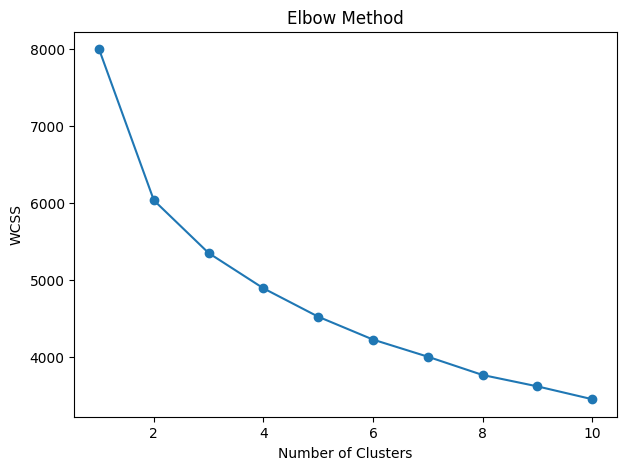

In [ ]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

k means model

In [ ]:
kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans_model.fit_predict(X_scaled)

df["Cluster"] = clusters

silhouette score

In [ ]:
score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", score)


Silhouette Score: 0.1741060445115868


PCA

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

cluster visualisation

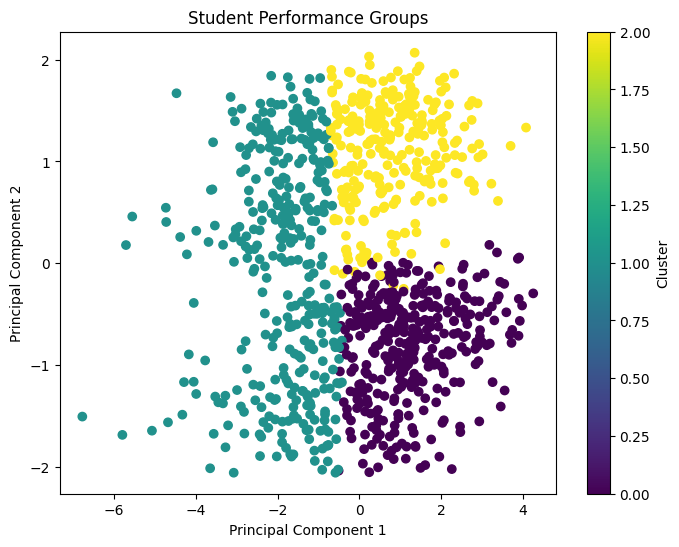

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("Student Performance Groups")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

cluster summary

In [ ]:

print("\nStudents in each Cluster")

print(df["Cluster"].value_counts())



Students in each Cluster
Cluster
1    362
0    354
2    284
Name: count, dtype: int64


means value of each cluster

In [ ]:
print("\nCluster-wise Mean")

print(df.groupby("Cluster").mean())



Cluster-wise Mean
           gender  race/ethnicity  parental level of education     lunch  \
Cluster                                                                    
0        0.000000        2.338983                     2.375706  0.751412   
1        0.546961        1.787293                     2.646409  0.436464   
2        1.000000        2.461268                     2.419014  0.778169   

         test preparation course  math score  reading score  writing score  
Cluster                                                                     
0                       0.562147   71.387006      79.884181      80.163842  
1                       0.817680   51.588398      54.685083      52.701657  
2                       0.517606   77.968310      74.274648      72.528169  


save result

In [ ]:
df.to_csv("Student_Performance_Clusters.csv", index=False)

print("\nClustered dataset saved successfully!")


Clustered dataset saved successfully!


correlation heatmap

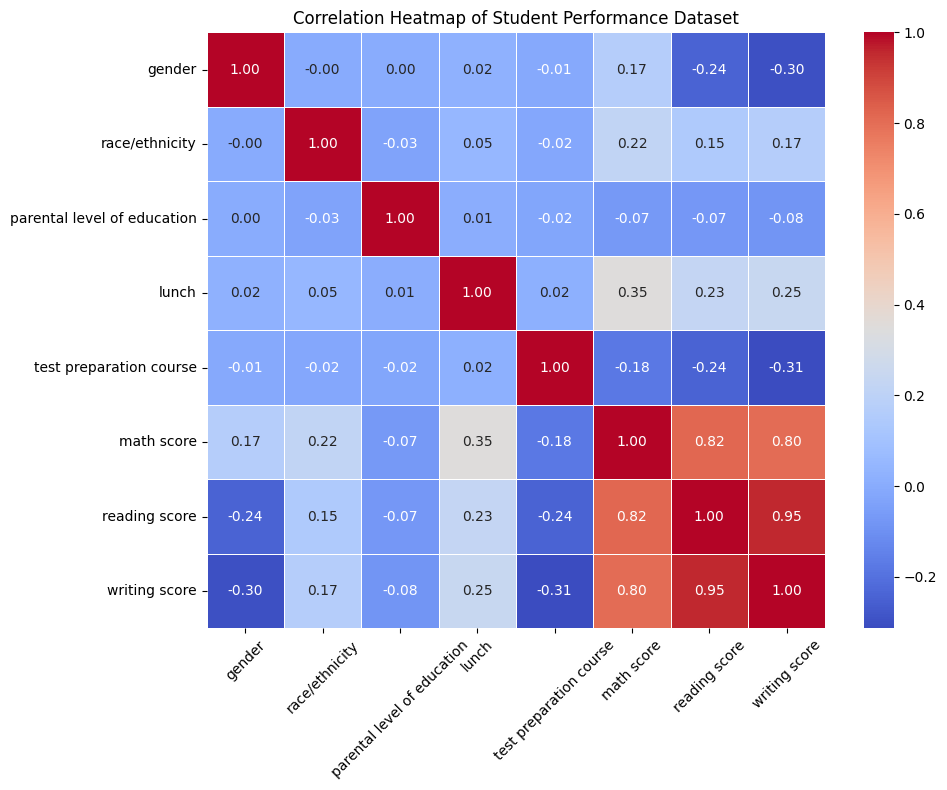

In [ ]:
# ==========================================
# Correlation Heatmap
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Student Performance Dataset")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()